--- Generating Validation Chart: Sum of Profiles vs. Total Consumption ---
Success! Integrity check chart saved at: ..\figuras\figure-validation-sum-check.pdf
If the Green Circles overlap the Black Line, your profile math is correct.


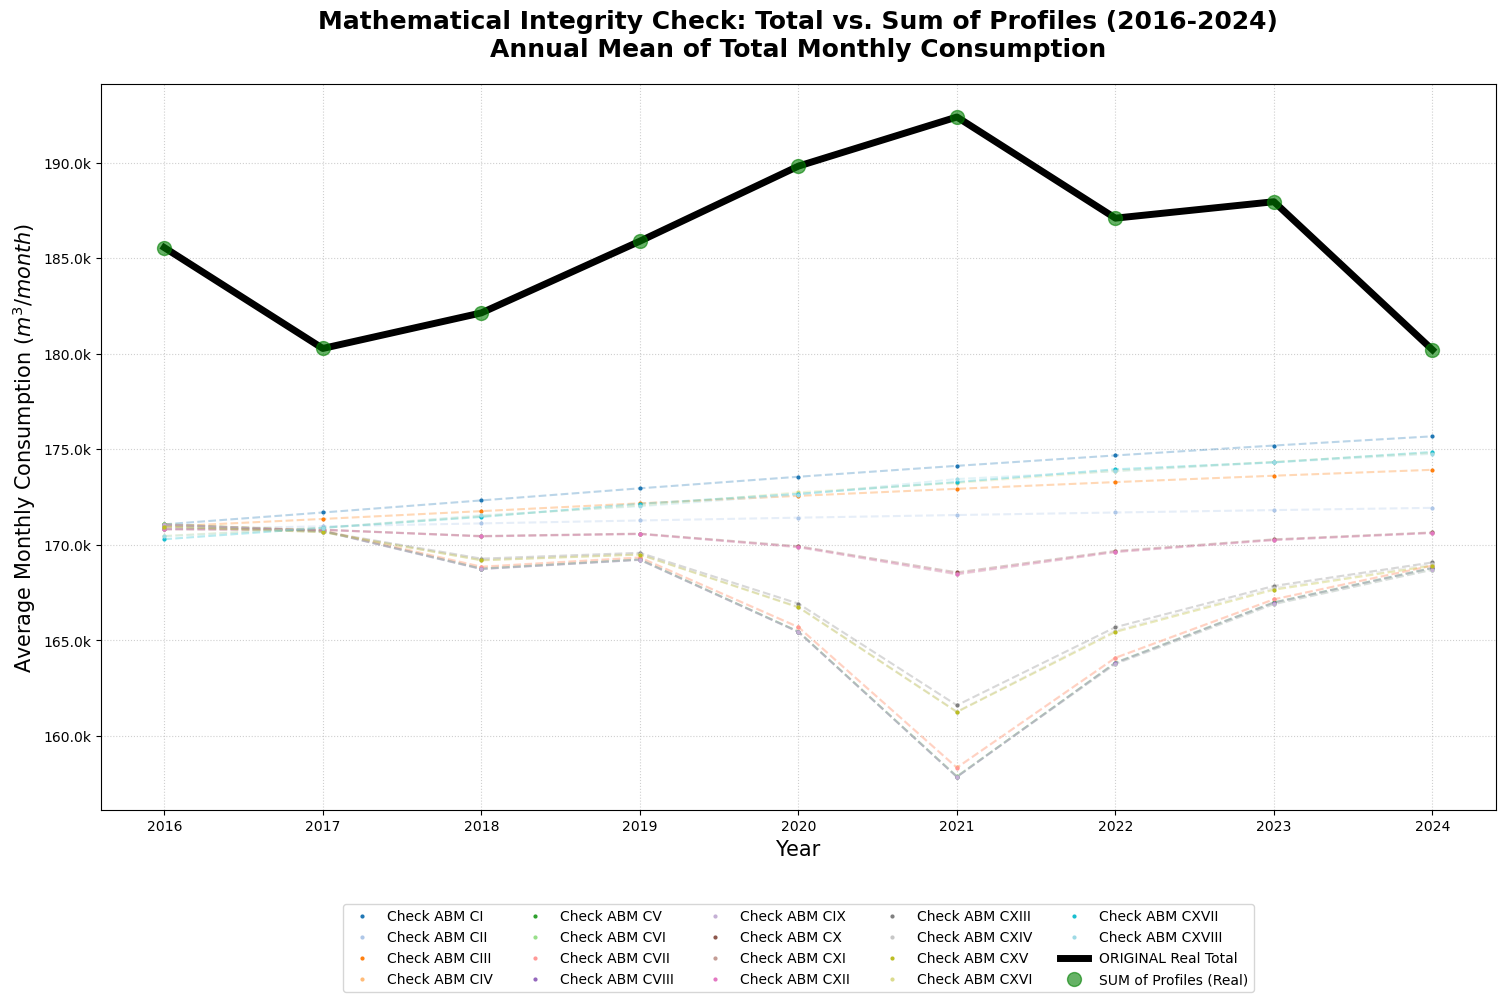

: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os

# ==========================================
# 1. Configurations and Paths
# ==========================================
BASE_PATH = '..' 

# Input Filenames
BASELINE_FILE = 'Tabela_consumidores_Itapua_com_setor_comportamento_e_renda_2015.csv'
HISTORY_120M = 'Tabela_consumo_Itapua_120m.csv'
TOTAL_HISTORY_FILE = 'Tabela_consumo_real_historico_2016_2025.csv'
SIM_FILE = 'simulacao_hindcasting_2016_2025.csv'

# Output Configuration
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG_SUM = 'figure-validation-sum-check.pdf'

# Search Directories
INPUT_DIR_INCLUDES = os.path.join(BASE_PATH, 'includes')
INPUT_DIR_RESULTS = os.path.join(BASE_PATH, 'resultados')

def classify_profile(daily_liters):
    if daily_liters < 100.0: return 'AMBIENTALISTA'
    elif daily_liters <= 121.5: return 'MODERADO'
    else: return 'PERDULARIO'

def aggregate_annually_mean(df, date_col, value_cols):
    df_yearly = df.copy()
    df_yearly['Year'] = df_yearly[date_col].dt.year
    return df_yearly.groupby('Year')[value_cols].mean().reset_index()

def main():
    print("--- Generating Validation Chart: Sum of Profiles vs. Total Consumption ---")

    # ==========================================
    # 2. Data Preparation
    # ==========================================
    
    # A. Load Real Total Data
    path_total = os.path.join(INPUT_DIR_INCLUDES, TOTAL_HISTORY_FILE)
    df_real_total = pd.read_csv(path_total, sep=';', decimal='.')
    df_real_total['Date'] = pd.to_datetime(df_real_total['AM_REFERENCIA'].astype(str) + '01', format='%Y%m%d')
    df_real_total.rename(columns={'real_total_consumption': 'Original_Real_Total'}, inplace=True)

    # B. Calculate Real Proportions (Same logic as behavioral scripts)
    path_baseline = os.path.join(INPUT_DIR_INCLUDES, BASELINE_FILE)
    df_residents = pd.read_csv(path_baseline, sep=';')[['SK_MATRICULA', 'NN_MORADORES_ANALISE']]
    
    path_120m = os.path.join(INPUT_DIR_INCLUDES, 'dados', HISTORY_120M)
    df_120m = pd.read_csv(path_120m, sep=';', decimal=',')
    df_120m = df_120m[(df_120m['AM_REFERENCIA'] >= 201601) & (df_120m['AM_REFERENCIA'] <= 202512)]

    df_dynamic = pd.merge(df_120m, df_residents, on='SK_MATRICULA')
    df_dynamic['L_P_DAY'] = (df_dynamic['HCLQTCON'] * 1000 / df_dynamic['NN_MORADORES_ANALISE']) / 30.5
    df_dynamic['PROFILE'] = df_dynamic['L_P_DAY'].apply(classify_profile)
    
    # Calculate monthly proportions (Sum of parts must be 1.0)
    monthly_sum = df_dynamic.groupby(['AM_REFERENCIA', 'PROFILE'])['HCLQTCON'].sum().unstack(fill_value=0)
    monthly_prop = monthly_sum.div(monthly_sum.sum(axis=1), axis=0).reset_index()
    profiles_list = ['AMBIENTALISTA', 'MODERADO', 'PERDULARIO']

    # C. Reconstruct Real Total from Profiles
    df_check_real = pd.merge(df_real_total, monthly_prop, on='AM_REFERENCIA')
    df_check_real['Sum_Real_Profiles'] = 0.0
    for p in profiles_list:
        # Vol_Profile = Total * Proportion
        df_check_real['Sum_Real_Profiles'] += df_check_real['Original_Real_Total'] * df_check_real.get(p, 0.0)

    # D. Reconstruct Simulation Totals from Profiles
    path_sim = os.path.join(INPUT_DIR_RESULTS, SIM_FILE)
    df_sim = pd.read_csv(path_sim, sep=';', decimal=',')
    df_sim['Date'] = pd.to_datetime(df_sim['Ano'].astype(str) + '-' + df_sim['Mes'].astype(str) + '-01')
    df_sim['AM_REFERENCIA'] = (df_sim['Ano'] * 100 + df_sim['Mes']).astype(int)
    
    sim_cols = [c for c in df_sim.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date', 'AM_REFERENCIA']]
    
    # For each scenario, we apply the same proportion logic to check consistency
    df_check_sim = pd.merge(df_sim, monthly_prop, on='AM_REFERENCIA')
    for col in sim_cols:
        scen_sum_col = f"Sum_Profiles_{col}"
        df_check_sim[scen_sum_col] = 0.0
        for p in profiles_list:
            df_check_sim[scen_sum_col] += df_check_sim[col] * df_check_sim.get(p, 0.0)

    # E. Annual Aggregation for Plotting
    sum_sim_cols = [f"Sum_Profiles_{c}" for c in sim_cols]
    df_real_annual = aggregate_annually_mean(df_check_real, 'Date', ['Original_Real_Total', 'Sum_Real_Profiles'])
    df_sim_annual = aggregate_annually_mean(df_check_sim, 'Date', sim_cols + sum_sim_cols)

    # ==========================================
    # 3. Plotting
    # ==========================================
    fig, ax = plt.subplots(figsize=(18, 11))

    # --- A. ABM Totals (Original vs Summed) ---
    palette = plt.cm.tab20(np.linspace(0, 1, len(sim_cols)))
    for i, col in enumerate(sim_cols):
        scen_id = col.split('_')[0]
        # Original Simulation Total (Line)
        ax.plot(df_sim_annual['Year'], df_sim_annual[col], color=palette[i], 
                linestyle='--', linewidth=1.5, alpha=0.3)
        # Reconstructed Simulation Total (Points - to check if they sit on the line)
        ax.plot(df_sim_annual['Year'], df_sim_annual[f"Sum_Profiles_{col}"], color=palette[i],
                linestyle='None', marker='.', markersize=4, label=f"Check ABM {scen_id}")

    # --- B. Real Totals (Original vs Summed) ---
    # Original Real Total (Thick Black Line)
    ax.plot(df_real_annual['Year'], df_real_annual['Original_Real_Total'], 
            label='ORIGINAL Real Total', color='black', linestyle='-', linewidth=5, zorder=10)
    
    # Reconstructed Real Total (Green Circles - should perfectly overlap the black line)
    ax.plot(df_real_annual['Year'], df_real_annual['Sum_Real_Profiles'], 
            label='SUM of Profiles (Real)', color='green', linestyle='None', 
            marker='o', markersize=10, alpha=0.6, zorder=11)

    # Formatting
    ax.set_title('Mathematical Integrity Check: Total vs. Sum of Profiles (2016-2025)\n'
                 'Annual Mean of Total Monthly Consumption', fontsize=18, fontweight='bold', pad=20)
    ax.set_ylabel('Average Monthly Consumption ($m^3/month$)', fontsize=15)
    ax.set_xlabel('Year', fontsize=15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.1f}k'))
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Footer Legend
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5, fontsize=10)
    plt.subplots_adjust(bottom=0.22)

    # Save
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG_SUM)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Success! Integrity check chart saved at: {save_path}")
    print("If the Green Circles overlap the Black Line, your profile math is correct.")
    plt.show()

if __name__ == "__main__":
    main()